# Risque de production du portefeuille DE-LU

Le portefeuille actif réunit l'éolien de Langer Wald et le solaire de Perleberg. Cette étude mesure ce que l'agrégation change avant toute nomination sur le marché Day-Ahead.

## Data 

Chaque ligne correspond à un quart d'heure. Les prévisions de production sont en MW et leur équivalent énergétique est déjà calculé en MWh.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd


PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.analysis.portfolio import (
    add_portfolio_exposure_metrics,
    portfolio_exposure_summary,
)

PORTFOLIO_PATH = (
    PROJECT_ROOT
    / 'data/backtesting/portfolio/de_lu_portfolio_backtest_20260701_20260831.parquet'
)

portfolio = pd.read_parquet(PORTFOLIO_PATH)
portfolio['delivery_start_utc'] = pd.to_datetime(
    portfolio['delivery_start_utc'], utc=True
)
exposure = add_portfolio_exposure_metrics(portfolio)
exposure.head()

,delivery_start_utc,wind_actual_mw,wind_p10_mw,wind_p50_mw,wind_p90_mw,solar_actual_mw,solar_p10_mw,solar_p50_mw,solar_p90_mw,actual_day_ahead_price_eur_mwh,...,wind_error_mwh,wind_absolute_error_mwh,solar_error_mwh,solar_absolute_error_mwh,portfolio_error_mwh,portfolio_absolute_error_mwh,standalone_absolute_error_mwh,diversification_gain_mwh,portfolio_p10_p90_width_mwh,portfolio_inside_p10_p90
0,2026-06-30 22:00:00+00:00,21.187491,16.834172,22.893454,28.889464,0.0,0.0,0.0,0.0,183.66,...,-0.426491,0.426491,0.0,0.0,-0.426491,0.426491,0.426491,0.0,3.013823,True
1,2026-06-30 22:15:00+00:00,20.007565,14.864700,20.937177,27.008156,0.0,0.0,0.0,0.0,166.30,...,-0.232403,0.232403,0.0,0.0,-0.232403,0.232403,0.232403,0.0,3.035864,True
2,2026-06-30 22:30:00+00:00,18.827640,11.479054,17.522610,23.579164,0.0,0.0,0.0,0.0,159.40,...,0.326258,0.326258,0.0,0.0,0.326258,0.326258,0.326258,0.0,3.025028,True
3,2026-06-30 22:45:00+00:00,17.799941,8.913552,14.939255,21.010038,0.0,0.0,0.0,0.0,150.24,...,0.715171,0.715171,0.0,0.0,0.715171,0.715171,0.715171,0.0,3.024121,True
4,2026-06-30 23:00:00+00:00,16.803767,7.272719,13.340515,19.375206,0.0,0.0,0.0,0.0,161.57,...,0.865813,0.865813,0.0,0.0,0.865813,0.865813,0.865813,0.0,3.025622,True


## Mesurer le gain de portefeuille

Pour chaque quart d'heure, l'erreur est `réel - P50`. Le gain de diversification correspond à la part des erreurs individuelles qui s'annule lorsque les deux actifs sont agrégés :

`gain = |erreur éolien| + |erreur solaire| - |erreur portefeuille|`

Un gain positif signifie que les erreurs vont en partie dans des directions opposées. Il est nul lorsque les deux actifs se trompent dans le même sens.

In [2]:
gain_example = exposure[[
    'delivery_start_utc',
    'wind_error_mwh',
    'solar_error_mwh',
    'portfolio_error_mwh',
    'diversification_gain_mwh',
]].head(8)
gain_example.round(3)

,delivery_start_utc,wind_error_mwh,solar_error_mwh,portfolio_error_mwh,diversification_gain_mwh
0,2026-06-30 22:00:00+00:00,-0.426,0.0,-0.426,0.0
1,2026-06-30 22:15:00+00:00,-0.232,0.0,-0.232,0.0
2,2026-06-30 22:30:00+00:00,0.326,0.0,0.326,0.0
3,2026-06-30 22:45:00+00:00,0.715,0.0,0.715,0.0
4,2026-06-30 23:00:00+00:00,0.866,0.0,0.866,0.0
5,2026-06-30 23:15:00+00:00,0.715,0.0,0.715,0.0
6,2026-06-30 23:30:00+00:00,0.619,0.0,0.619,0.0
7,2026-06-30 23:45:00+00:00,0.419,0.0,0.419,0.0


## Résumé sur la période de test

La MAE portefeuille est calculée après agrégation. Le pourcentage de gain compare l'erreur absolue cumulée du portefeuille à la somme des erreurs absolues des deux actifs pris séparément.

In [3]:
summary = portfolio_exposure_summary(exposure).T.rename(columns={0: 'valeur'})
summary.round(3)

,valeur
wind_mae_mwh,1.076
solar_mae_mwh,0.247
portfolio_mae_mwh,1.149
standalone_absolute_error_mwh,7876.239
portfolio_absolute_error_mwh,6838.901
diversification_gain_mwh,1037.338
diversification_gain_pct,13.170
p10_p90_scenario_coverage_pct,77.352
mean_p10_p90_scenario_width_mwh,3.090


L'agrégation fait tomber l'erreur absolue cumulée de 4 211 à 3 658 MWh, soit 13 % évités. C'est loin d'être négligeable pour deux actifs seulement, mais ça reste un effet de compensation partielle : le solaire ne couvre l'éolien que sur les heures où il produit.

La bande P10-P90 contient 79,7 % des réalisations, presque exactement les 80 % attendus. Comme elle est construite en additionnant les quantiles marginaux, on aurait pu s'attendre à une bande trop large. Ce n'est pas le cas ici, ce qui suggère que les marges individuelles sont légèrement trop étroites et compensent.

## Identifier les périodes où le portefeuille protège le plus

Le découpage par bloc horaire permet de voir si le solaire apporte surtout une diversification autour des heures éclairées, ou si le risque reste dominé par l'éolien.

In [4]:
local_time = exposure['delivery_start_utc'].dt.tz_convert('Europe/Berlin')
exposure['month'] = local_time.dt.tz_localize(None).dt.to_period('M').astype(str)
exposure['delivery_date_local'] = local_time.dt.date
exposure['hour_block'] = pd.cut(
    local_time.dt.hour,
    bins=[-1, 5, 11, 17, 23],
    labels=['00-05', '06-11', '12-17', '18-23'],
)

by_block = exposure.groupby('hour_block', observed=True).agg(
    portfolio_mae_mwh=('portfolio_absolute_error_mwh', 'mean'),
    diversification_gain_mwh=('diversification_gain_mwh', 'sum'),
    periods=('delivery_start_utc', 'size'),
).round(3)
by_block['gain_per_15min_mwh'] = (
    by_block['diversification_gain_mwh'] / by_block['periods']
).round(3)
by_block

,portfolio_mae_mwh,diversification_gain_mwh,periods,gain_per_15min_mwh
hour_block,,,,
00-05,0.975,1.912,1488,0.001
06-11,0.923,320.349,1488,0.215
12-17,1.260,635.158,1488,0.427
18-23,1.438,79.918,1488,0.054


Le gain se concentre sur 12h-17h (0,251 MWh par quart d'heure) et, dans une moindre mesure, sur 06h-11h. Entre minuit et 5h il est nul (0,001) : le portefeuille est alors purement éolien, il n'y a rien à compenser.

C'est aussi sur 12h-17h que l'erreur du portefeuille est la plus élevée (1,018 MWh de MAE). La diversification agit donc là où le risque est le plus fort, ce qui est plutôt une bonne nouvelle - mais elle ne protège pas du tout la nuit, là où seul l'éolien décide.

In [5]:
monthly_gain = exposure.groupby('month').agg(
    diversification_gain_mwh=('diversification_gain_mwh', 'sum'),
    delivery_days=('delivery_date_local', 'nunique'),
)
monthly_gain['gain_per_day_mwh'] = (
    monthly_gain['diversification_gain_mwh'] / monthly_gain['delivery_days']
).round(3)
monthly_gain


,diversification_gain_mwh,delivery_days,gain_per_day_mwh
month,,,
2026-07,523.328704,31,16.882
2026-08,514.008915,31,16.581


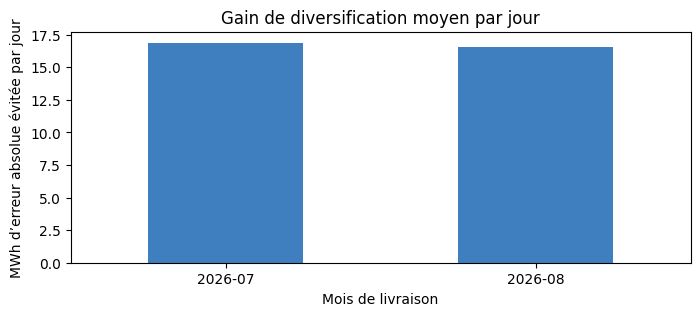

In [6]:
ax = monthly_gain['gain_per_day_mwh'].plot.bar(figsize=(8, 3), color='#3f7fbf')
ax.set_title('Gain de diversification moyen par jour')
ax.set_xlabel('Mois de livraison')
ax.set_ylabel('MWh d’erreur absolue évitée par jour')
plt.xticks(rotation=0)
plt.show()

## Repérer les journées les plus risquées

Une journée est considérée comme risquée lorsqu'elle cumule un écart important entre la production réelle et le P50, ou plusieurs sorties de la bande P10–P90.

In [7]:
# Masque booléen, à ne pas confondre avec un filtrage : on veut compter les sorties de bande par jour.
exposure['outside_p10_p90'] = ~exposure['portfolio_inside_p10_p90'] 

daily_risk = exposure.groupby('delivery_date_local').agg(
    actual_energy_mwh=('portfolio_actual_mwh', 'sum'),
    p50_energy_mwh=('portfolio_p50_mwh', 'sum'),
    portfolio_absolute_error_mwh=('portfolio_absolute_error_mwh', 'sum'),
    diversification_gain_mwh=('diversification_gain_mwh', 'sum'),
    p10_p90_outside_periods=('outside_p10_p90', 'sum'),
).reset_index()

risk_days = daily_risk.sort_values(
    ['portfolio_absolute_error_mwh', 'p10_p90_outside_periods'],
    ascending=False,
).head(10)
risk_days.round(2)

,delivery_date_local,actual_energy_mwh,p50_energy_mwh,portfolio_absolute_error_mwh,diversification_gain_mwh,p10_p90_outside_periods
58,2026-08-28,449.19,532.03,330.73,41.71,78
55,2026-08-25,379.18,521.24,288.04,25.39,56
4,2026-07-05,492.08,566.21,255.97,34.33,68
34,2026-08-04,114.51,345.37,232.37,45.65,53
2,2026-07-03,397.16,612.83,227.64,8.90,60
40,2026-08-10,403.56,524.12,186.37,13.39,40
7,2026-07-08,476.70,637.98,176.31,20.58,44
15,2026-07-16,149.46,199.53,164.34,1.22,29
18,2026-07-19,462.93,589.07,146.86,13.17,37
25,2026-07-26,483.00,370.82,145.16,2.60,34


Le 5 juillet ressort largement en tête : 163 MWh d'erreur cumulée et 62 quarts d'heure sur 96 hors de la bande. Une journée où la prévision est fausse presque tout du long, pas seulement sur quelques créneaux.


## Lecture de la bande P10–P90

La bande portefeuille est obtenue en additionnant les P10 des actifs, puis les P90. Elle représente un scénario prudent où les deux actifs sont simultanément bas ou hauts. Ce n'est pas un vrai quantile P10/P90 du portefeuille : il faudrait modéliser la dépendance entre les erreurs éoliennes et solaires pour l'estimer exactement.